# Explorando cv2

In [1]:
import cv2
import dlib
import matplotlib.pyplot as plt
import seaborn
from os import listdir, path, makedirs
from os.path import isfile, join
import shutil
import numpy as np

from sklearn.metrics import accuracy_score
from scipy.spatial import distance as dist

from io import BytesIO
from IPython.display import clear_output, Image, display
from PIL import Image as Img

In [2]:
img = cv2.imread('images/girl.jpg')

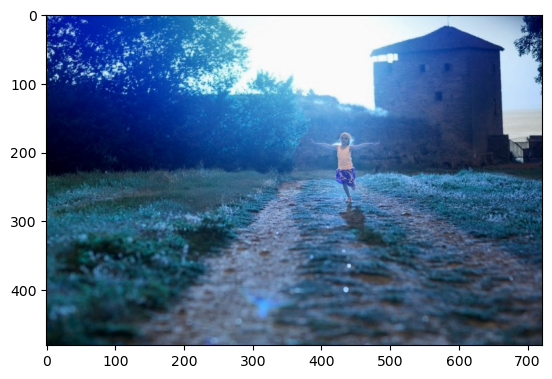

In [3]:
plt.imshow(img)

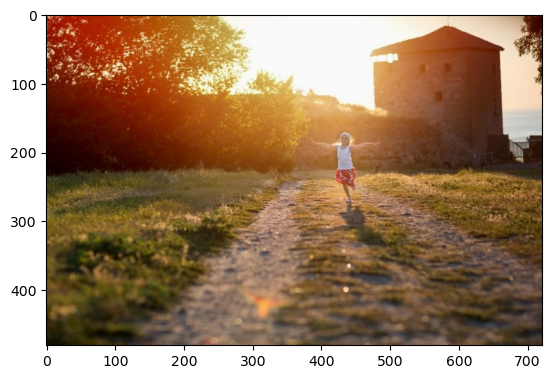

In [4]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)

In [5]:
img_rgb.shape

(481, 722, 3)

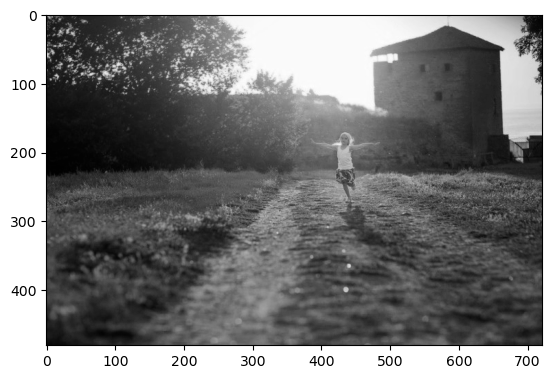

In [6]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(img_gray, cmap = 'gray')

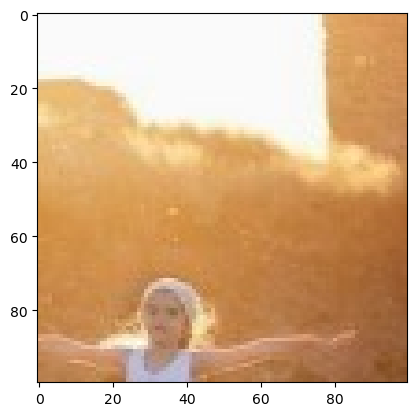

In [7]:
img_roi = img_rgb[100:200, 400:500]
plt.imshow(img_roi)

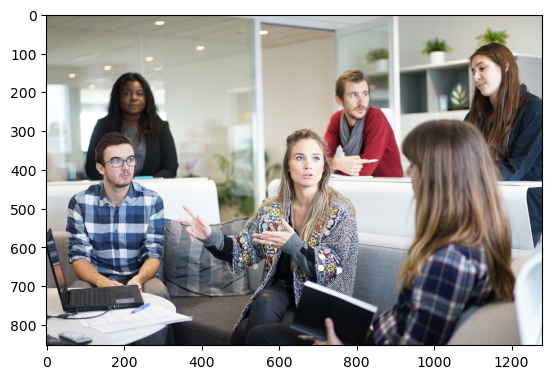

In [8]:
img = cv2.imread('images/px-people.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [9]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
classifier = cv2.CascadeClassifier('classificadores/haarcascade_frontalface_default.xml')
faces = classifier.detectMultiScale(img_gray, 1.2, 5)

In [10]:
print(faces, '\n\ntamanho: ', len(faces))

[[ 189  175   76   76]
 [1090  103   98   98]
 [ 766  173   87   87]
 [ 619  325  116  116]
 [ 153  339   96   96]] 

tamanho:  5


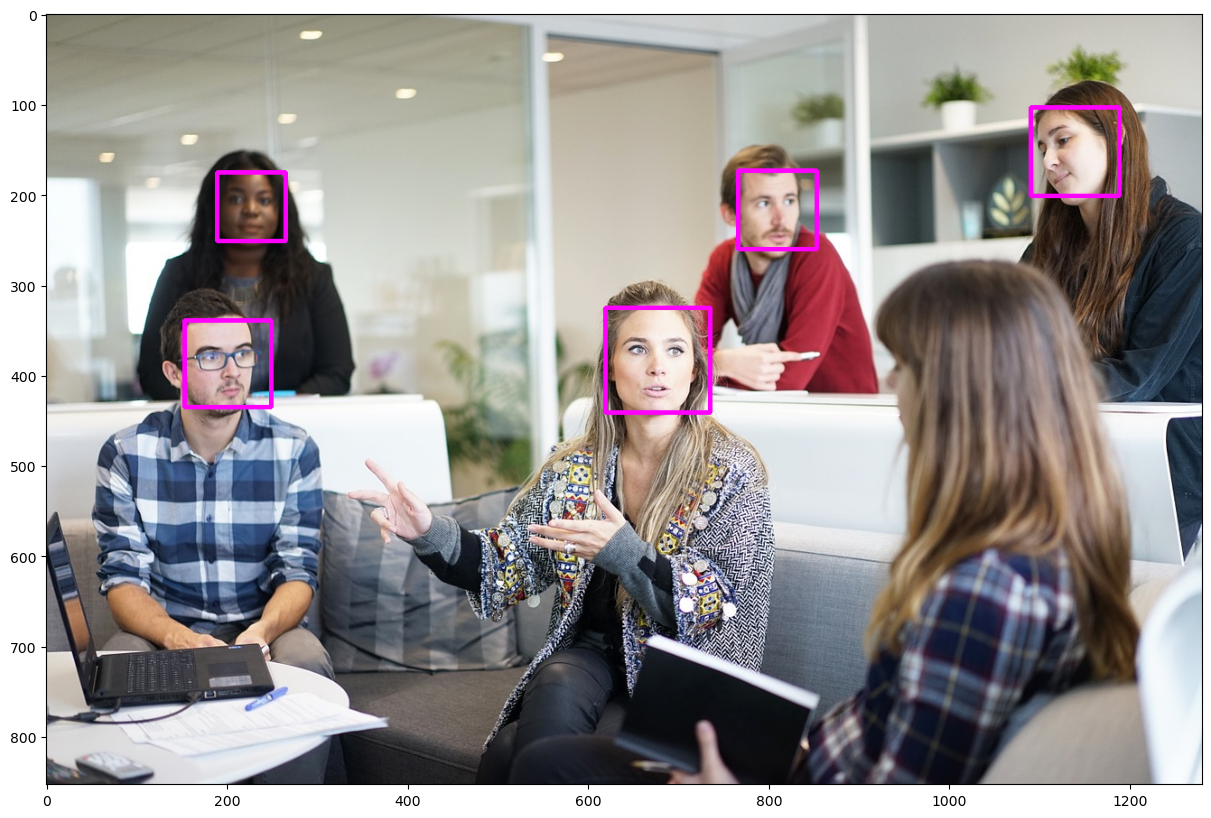

In [11]:
img_anotada = img.copy()

for (x,y,w,h) in faces:
    cv2.rectangle(img_anotada, (x,y), (x+w, y+h), (255,0,255), 3)

plt.figure(figsize=(20,10))
plt.imshow(img_anotada)

Dividindo as imagens de cada rosto

In [12]:
face_img = 0

for (x,y,w,h) in faces:
    face_img +=1
    img_roi = img[y:y+h, x:x+w]
    img_roi = cv2.cvtColor(img_roi, cv2.COLOR_RGB2BGR)
    cv2.imwrite('face_' + str(face_img) + '.png', img_roi)

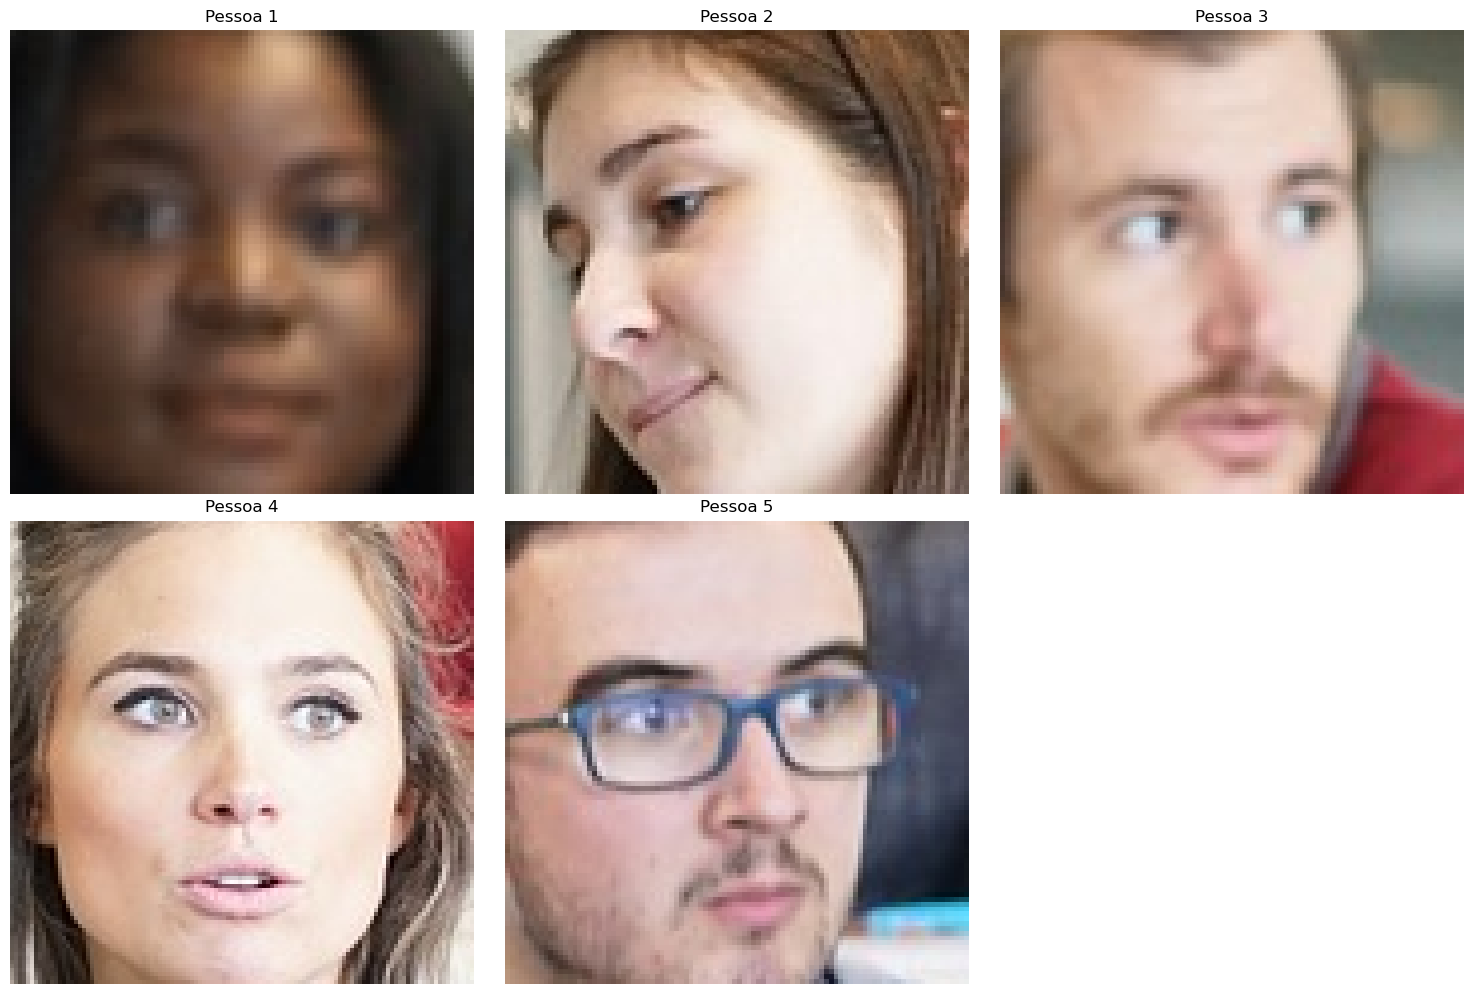

In [13]:
img_face_1 = cv2.imread('face_1.png')
img_face_1 = cv2.cvtColor(img_face_1, cv2.COLOR_BGR2RGB)

img_face_2 = cv2.imread('face_2.png')
img_face_2 = cv2.cvtColor(img_face_2, cv2.COLOR_BGR2RGB)

img_face_3 = cv2.imread('face_3.png')
img_face_3 = cv2.cvtColor(img_face_3, cv2.COLOR_BGR2RGB)

img_face_4 = cv2.imread('face_4.png')
img_face_4 = cv2.cvtColor(img_face_4, cv2.COLOR_BGR2RGB)

img_face_5 = cv2.imread('face_5.png')
img_face_5 = cv2.cvtColor(img_face_5, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

fig.delaxes(axes[1, 2])

axes[0, 0].imshow(img_face_1)
axes[0, 0].set_title('Pessoa 1')
axes[0, 0].axis('off')

axes[0, 1].imshow(img_face_2)
axes[0, 1].set_title('Pessoa 2')
axes[0, 1].axis('off')

axes[0, 2].imshow(img_face_3)
axes[0, 2].set_title('Pessoa 3')
axes[0, 2].axis('off')

axes[1, 0].imshow(img_face_4)
axes[1, 0].set_title('Pessoa 4')
axes[1, 0].axis('off')

axes[1, 1].imshow(img_face_5)
axes[1, 1].set_title('Pessoa 5')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

plt.show()

In [14]:
imgs = [img_face_1.shape, img_face_2.shape,
        img_face_3.shape, img_face_4.shape,
        img_face_5.shape]

imgs

[(76, 76, 3), (98, 98, 3), (87, 87, 3), (116, 116, 3), (96, 96, 3)]

# Classificação de face com outras imagens

In [15]:
faces_caminho = 'images/cropped_faces/'
lista_arq_faces = [f for f in listdir(faces_caminho) if isfile(join(faces_caminho, f))]

In [16]:
len(lista_arq_faces)

750

## Divisão das imagens de treino e teste + padronização tamanho imagens

In [17]:
path_train = 'images/train/'
path_test = 'images/test/'

if not path.exists(path_train):
    makedirs(path_train)

if not path.exists(path_test):
    makedirs(path_test)

for arq in lista_arq_faces:
    sujeito = arq[1:3]
    numero = arq[4:6]

    if int(numero) <= 10:
        shutil.copyfile(faces_caminho + arq, path_train + arq)
    else:
        shutil.copyfile(faces_caminho + arq, path_test + arq)

In [18]:
def padronizar_img(img_caminho):
    img = cv2.imread(img_caminho, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (200,200), interpolation=cv2.INTER_LANCZOS4)
    return img

Foi necessário criar uma pasta e dividir com as imagens de treino(10 imagens) e teste(5 imagens). Após isso, foi preciso adicionar as imagens em uma variável específica para treino e teste fazendo a divisão da imagem e id do sujeito.

In [19]:
lista_arq_faces_train = [f for f in listdir(path_train) if isfile(join(path_train, f))]
lista_arq_faces_test = [f for f in listdir(path_test) if isfile(join(path_test, f))]

In [20]:
len(lista_arq_faces_train), len(lista_arq_faces_test)

(500, 250)

In [21]:
data_train, sujeitos = [], []

for i, arq in enumerate(lista_arq_faces_train):
    img_path = path_train + arq
    img = padronizar_img(img_path)
    data_train.append(img)
    sujeito = arq[1:3]
    sujeitos.append(int(sujeito))

In [22]:
len(data_train), len(sujeitos)

(500, 500)

In [23]:
data_test, sujeitos_test = [], []

for i, arq in enumerate(lista_arq_faces_test):
    img_path = path_test + arq
    img = padronizar_img(img_path)
    data_test.append(img)
    sujeito = arq[1:3]
    sujeitos_test.append(int(sujeito))

In [24]:
len(data_test), len(sujeitos_test)

(250, 250)

Text(0.5, 1.0, '1')

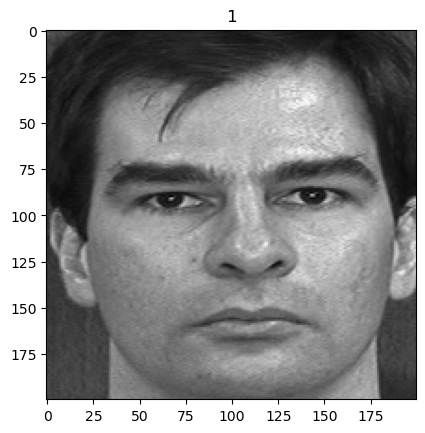

In [25]:
plt.imshow(data_train[0], cmap='gray')
plt.title(sujeitos[0])

Text(0.5, 1.0, '1')

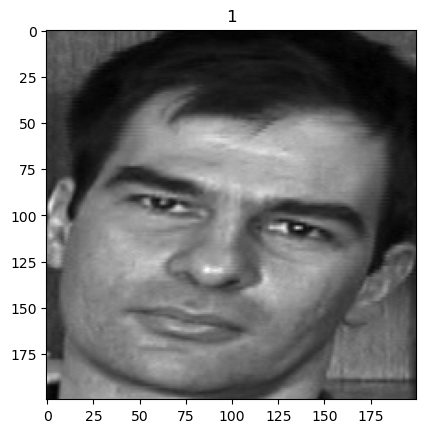

In [26]:
plt.imshow(data_test[0], cmap='gray')
plt.title(sujeitos_test[0])

### Algoritmo EigenFace

In [27]:
sujeitos = np.asarray(sujeitos, dtype=np.int32)
sujeitos_test = np.asarray(sujeitos_test, dtype=np.int32)

model_eingenfaces = cv2.face.EigenFaceRecognizer_create()
model_eingenfaces.train(data_train, sujeitos)

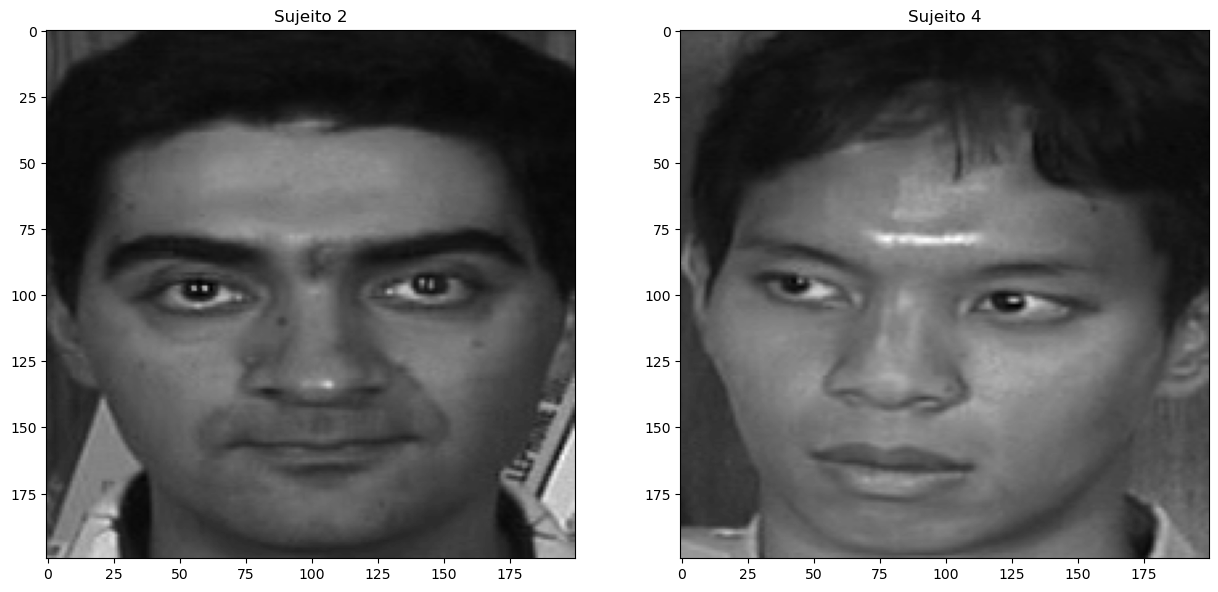

In [28]:
plt.figure(figsize=(15,10))

plt.subplot(121)
plt.title("Sujeito " + str(sujeitos_test[6]))
plt.imshow(data_test[6], cmap = 'gray')

plt.subplot(122)
plt.title("Sujeito " + str(sujeitos_test[19]))
plt.imshow(data_test[19], cmap = 'gray')

plt.show()

In [29]:
predict = model_eingenfaces.predict(data_test[6])
predict

(32, 4817.750027543926)

In [30]:
predict = model_eingenfaces.predict(data_test[19])
predict

(4, 3120.7833241229155)

Algoritmo acertou o sujeito 4

### Algoritmo FisherFace

In [31]:
model_fisherfaces = cv2.face.FisherFaceRecognizer_create()
model_fisherfaces.train(data_train, sujeitos)

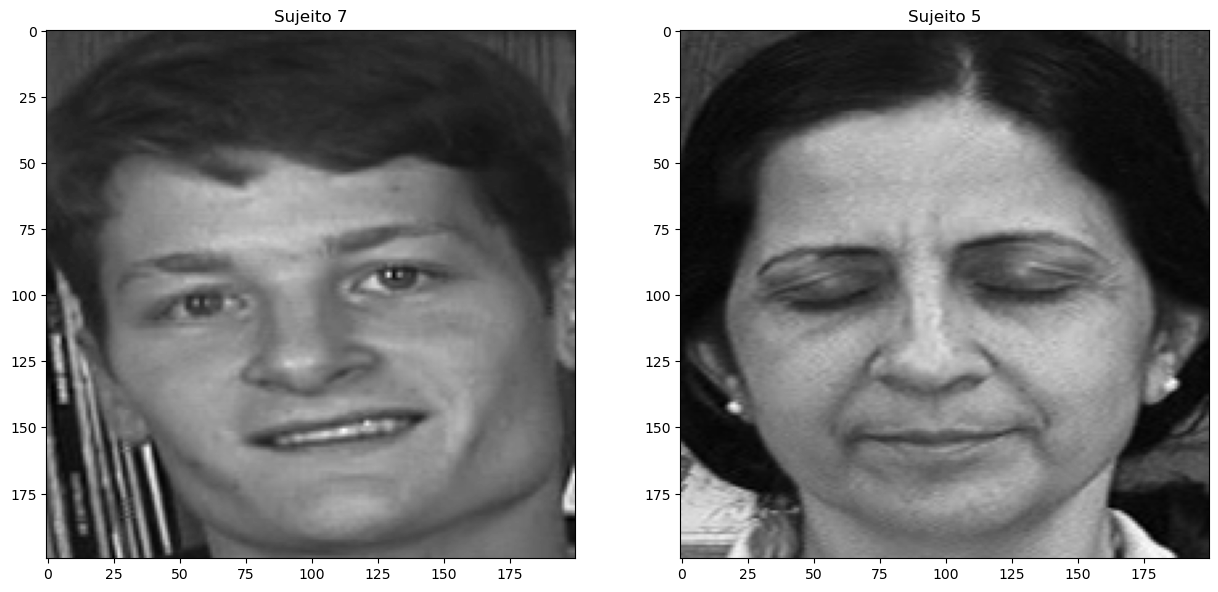

In [32]:
plt.figure(figsize=(15,10))

plt.subplot(121)
plt.title("Sujeito " + str(sujeitos_test[32]))
plt.imshow(data_test[32], cmap = 'gray')

plt.subplot(122)
plt.title("Sujeito " + str(sujeitos_test[21]))
plt.imshow(data_test[21], cmap = 'gray')

plt.show()

In [33]:
predict = model_fisherfaces.predict(data_test[32])
predict

(32, 1002.9413818357863)

In [34]:
predict = model_fisherfaces.predict(data_test[21])
predict

(5, 1066.93608751533)

Algoritmo acertou o sujeito 5

### Algoritmo LBPH

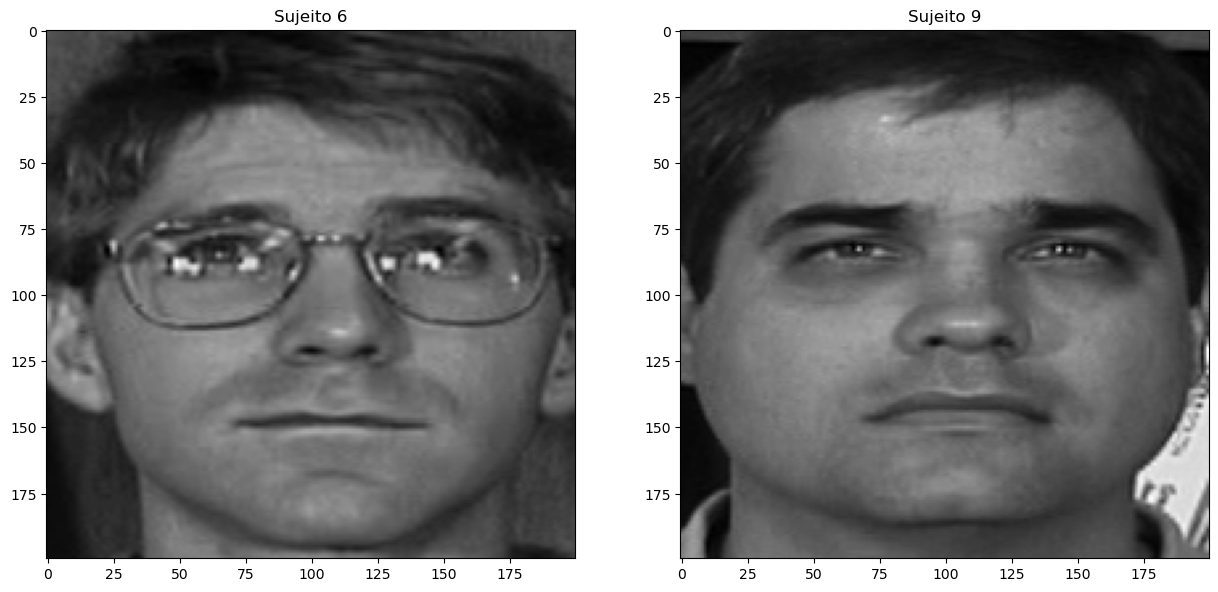

In [35]:
model_lbph = cv2.face.LBPHFaceRecognizer_create()
model_lbph.train(data_train, sujeitos)

plt.figure(figsize=(15,10))

plt.subplot(121)
plt.title("Sujeito " + str(sujeitos_test[27]))
plt.imshow(data_test[27], cmap = 'gray')

plt.subplot(122)
plt.title("Sujeito " + str(sujeitos_test[40]))
plt.imshow(data_test[40], cmap = 'gray')

plt.show()

In [36]:
predict = model_lbph.predict(data_test[27])
predict

(6, 36.49919959564635)

In [37]:
predict = model_lbph.predict(data_test[40])
predict

(9, 32.56558094783701)

Algoritmo acertou os dois sujeitos

## Avaliação de modelos

In [38]:
y_pred_eingenfaces = []

for _ in data_test:
    y_pred_eingenfaces.append(model_eingenfaces.predict(_)[0])

acc_eingenfaces = accuracy_score(sujeitos_test, y_pred_eingenfaces)

print(f'Acurácia Eingenfaces: {acc_eingenfaces}')

Acurácia Eingenfaces: 0.724


In [39]:
y_pred_fisher = []

for _ in data_test:
    y_pred_fisher.append(model_fisherfaces.predict(_)[0])

acc_fisher = accuracy_score(sujeitos_test, y_pred_fisher)

print(f'Acurácia FisherFaces: {acc_fisher}')

Acurácia FisherFaces: 0.52


In [40]:
y_pred_lbph = []

for _ in data_test:
    y_pred_lbph.append(model_lbph.predict(_)[0])

acc_lbph = accuracy_score(sujeitos_test, y_pred_lbph)

print(f'Acurácia LBPH: {acc_lbph}')

Acurácia LBPH: 0.792


# Estudo do DLib

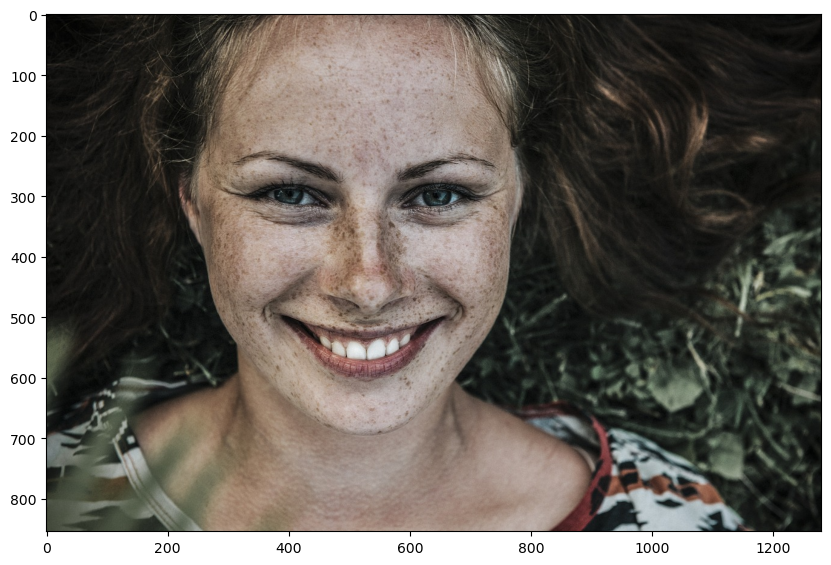

In [41]:
img = cv2.imread('images/px-woman-smilings.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)

In [42]:
classifier_dlib = dlib.shape_predictor('classificadores/shape_predictor_68_face_landmarks.dat')
detector_face = dlib.get_frontal_face_detector()

In [43]:
def anotar_rosto(img):
    retangulos = detector_face(img, 1)

    if len(retangulos) == 0:
        return None
        
    for k, d in enumerate(retangulos):
        print(f'identificado rosto {str(k)}')
        cv2.rectangle(img, (d.left(), d.top()), (d.right(), d.bottom()), (255,0,0), 3)

    return img

identificado rosto 0


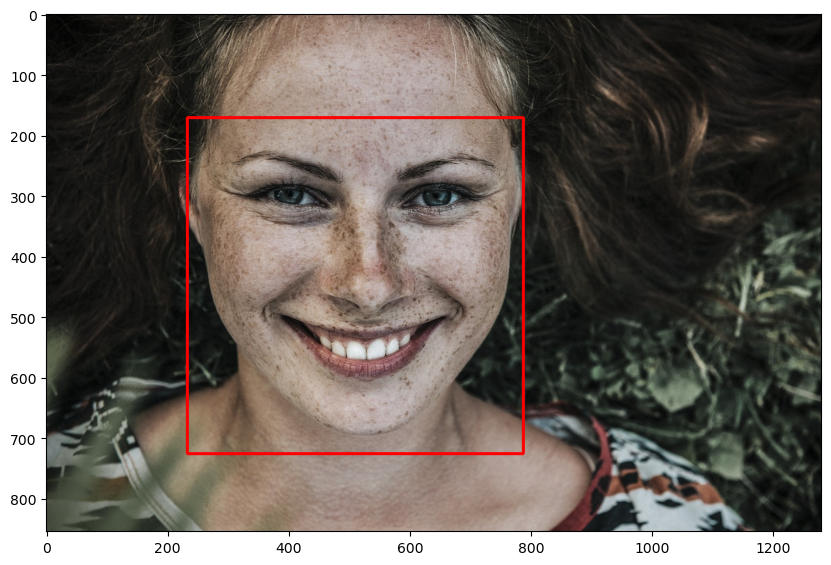

In [44]:
img_anotada = img.copy()
img_anotada = anotar_rosto(img_anotada)

plt.figure(figsize=(10,10))
plt.imshow(img_anotada)

Utiliza SVM classifier

## Extração dos marcos faciais

In [45]:
def pontos_marcos_faciais(img):
    retangulos = detector_face(img, 1)
    
    if len(retangulos) == 0:
        return None

    marcos = []
    for ret in retangulos:
        marcos.append(np.matrix([[p.x, p.y] for p in classifier_dlib(img, ret).parts()]))

    return marcos

In [46]:
marcos_faciais = pontos_marcos_faciais(img)

len(marcos_faciais), len(marcos_faciais[0])

(1, 68)

In [47]:
def anotar_marcos_faciais(img, marcos):
    
    for marco in marcos:
        for idx, ponto in enumerate(marco):
            centro = (ponto[0,0], ponto[0,1])
            cv2.circle(img, centro, 3, (0,255,255), -1)
            cv2.putText(img, str(idx), centro, cv2.FONT_HERSHEY_SIMPLEX, 
                        0.8, (255,255,255), 2)

    return img

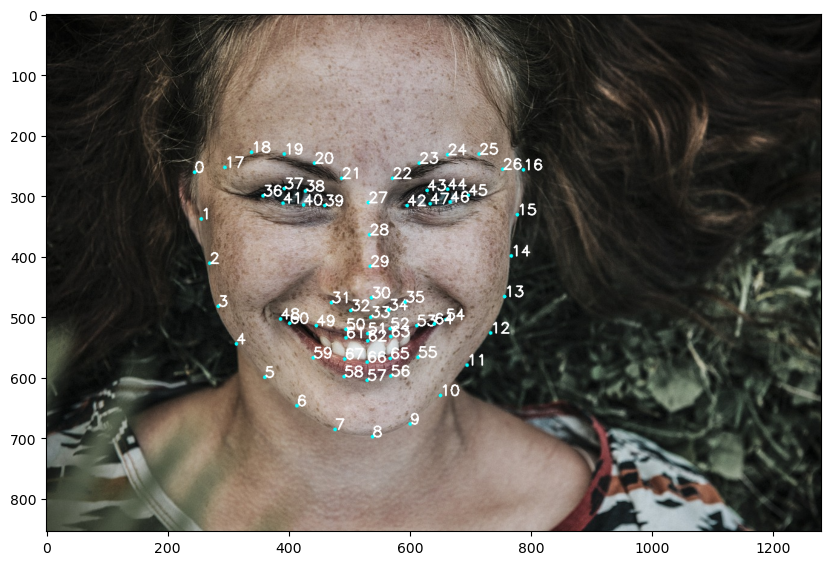

In [48]:
img_anotada = img.copy()
img_anotada = anotar_marcos_faciais(img_anotada, marcos_faciais)

plt.figure(figsize=(10,10))
plt.imshow(img_anotada)

In [49]:
FACE = list(range(17, 68))
FACE_COMPLETA = list(range(0, 68))
LABIO = list(range(48, 61))
SOMBRANCELHA_DIRETA = list(range(17, 22))
SOMBRANCELHA_ESQUERDA = list(range(22, 27))
OLHO_DIREITO = list(range(36,42))
OLHO_ESQUERDO = list(range(42,48))
NARIZ = list(range(27,35))
MANDIBULA = list(range(0,17))

In [50]:
def aspecto_razao_olhos(pontos_olhos):
    
    a = dist.euclidean(pontos_olhos[1], pontos_olhos[5])
    b = dist.euclidean(pontos_olhos[2], pontos_olhos[4])
    c = dist.euclidean(pontos_olhos[0], pontos_olhos[3])
    
    aspecto_razao = (a + b)/(2.0 * c)
    
    return aspecto_razao

In [51]:
def anotar_marcos_casca_convexa(img, marcos):
    retangulos = detector_face(img, 1)

    if len(retangulos) == 0:
        return None

    for idx, ret in enumerate(retangulos):
        marco = marcos[idx]
        
        pontos = cv2.convexHull(marco[OLHO_ESQUERDO])
        cv2.drawContours(img, [pontos], 0, (0,255,100), 3)

        pontos = cv2.convexHull(marco[OLHO_DIREITO])
        cv2.drawContours(img, [pontos], 0, (0,255,100), 3)

    return img

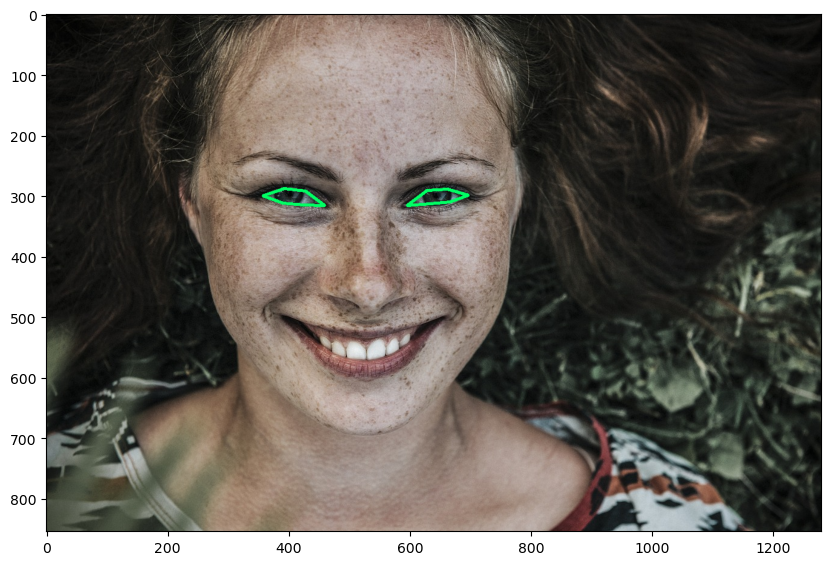

In [52]:
img_anotada = img.copy()
img_anotada = anotar_marcos_casca_convexa(img_anotada, marcos_faciais)

plt.figure(figsize=(10,10))
plt.imshow(img_anotada)

In [53]:
marcos_faciais[0][OLHO_ESQUERDO]

matrix([[596, 317],
        [629, 292],
        [663, 290],
        [697, 300],
        [667, 311],
        [634, 314]])

In [54]:
valor_olho_esquerdo = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_ESQUERDO]))
valor_olho_esquerdo

0.21450051712603885

In [55]:
valor_olho_direito = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_DIREITO]))
valor_olho_direito

0.22895527127621407

Assim podemos identificar se um olho está aberto ou fechado

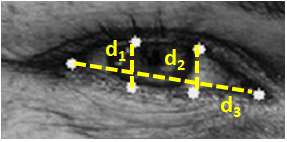

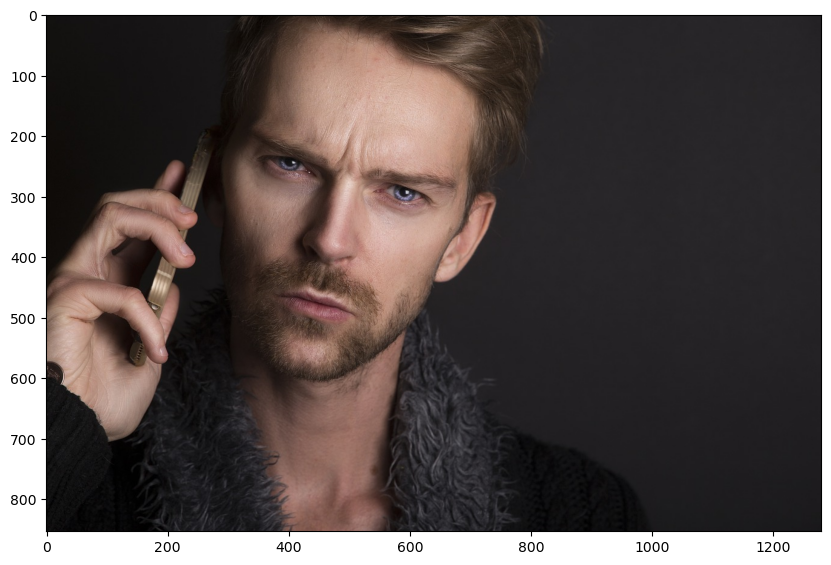

In [56]:
img = cv2.imread('images/px-man-serious.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(img)

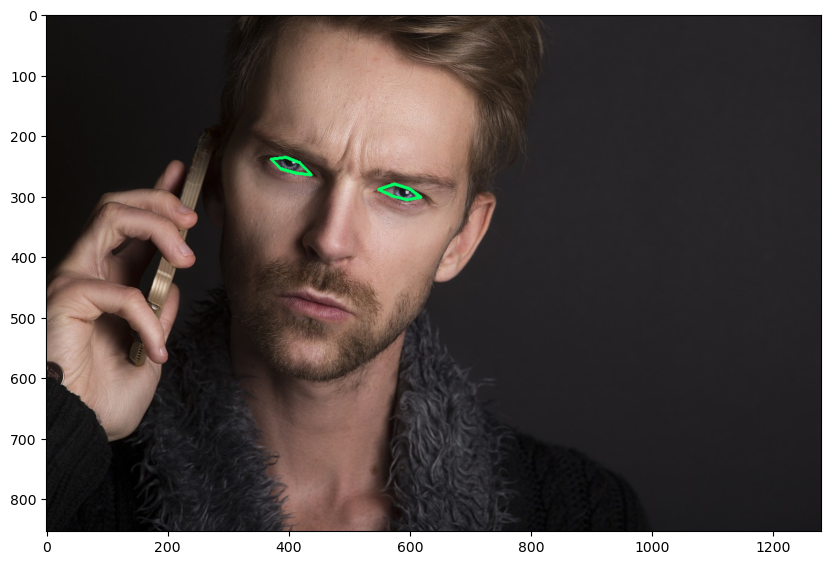

In [57]:
marcos_faciais = pontos_marcos_faciais(img)

img_anotada = img.copy()
img_anotada = anotar_marcos_casca_convexa(img_anotada, marcos_faciais)

plt.figure(figsize=(10,10))
plt.imshow(img_anotada)

In [58]:
valor_olho_direito = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_DIREITO]))
valor_olho_direito

0.27133313866169434

In [59]:
valor_olho_esquerdo = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_ESQUERDO]))
valor_olho_esquerdo

0.2715204726310253

In [60]:
def padronizar_imagem(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (500,400))
    return frame

def exibir_video(frame):
    img = Img.fromarray(frame, 'RGB')
    buffer = BytesIO()
    img.save(buffer, format="JPEG")
    display(Image(data=buffer.getvalue()))
    clear_output(wait=True)

In [64]:
video = cv2.VideoCapture('videos/expressoes.mov')

try:
    while(True):
        captura_ok, frame = video.read()
        if captura_ok:
            frame = padronizar_imagem(frame)
            exibir_video(frame)
except KeyboardInterrupt:
    video.release()
    print('Interrompido')

Interrompido


In [62]:
def aspecto_razao_boca(pontos_boca):
    a = dist.euclidean(pontos_boca[3], pontos_boca[9])
    b = dist.euclidean(pontos_boca[2], pontos_boca[10])
    c = dist.euclidean(pontos_boca[4], pontos_boca[8])
    d = dist.euclidean(pontos_boca[0], pontos_boca[6])

    aspecto_razao = (a+b+c)/(3.0*d)
    return aspecto_razao

In [63]:
def anotar_marcos_casca_convexa_boca(img, marcos):
    retangulos = detector_face(img, 1)

    if len(retangulos) == 0:
        return None

    for idx, ret in enumerate(retangulos):
        marco = marcos[idx]
        
        pontos = cv2.convexHull(marco[LABIO])
        cv2.drawContours(img, [pontos], 0, (0,255,100), 3)

    return img

In [66]:
try:
    ar_max = 0
    video = cv2.VideoCapture("videos/bocejo.mov")
    while(True):
        captura_ok, frame = video.read()
        if captura_ok:
            frame = padronizar_imagem(frame)
            marcos_faciais = pontos_marcos_faciais(frame)
            
            if marcos_faciais is not None:
                ar_boca = aspecto_razao_boca(np.array(marcos_faciais[0][LABIO]))
                ar_boca = round(ar_boca, 3)
                
                if ar_boca > ar_max:
                    ar_max = ar_boca
                
                info = "boca " + str(ar_boca) + " maximo " + str(ar_max)
                
                frame = anotar_marcos_casca_convexa_boca(frame, marcos_faciais)
                cv2.putText(frame, info, (20, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,0), 2)
            
            exibir_video(frame)
            
except KeyboardInterrupt:
    video.release()
    print("Interrompido")

Interrompido


In [74]:
try:
    min_olho_esq = 1
    min_olho_dir = 1
    
    video = cv2.VideoCapture("videos/olhos-fechados.mov")
    
    while(True):
        captura_ok, frame = video.read()
        frame = padronizar_imagem(frame)
        
        marcos_faciais = pontos_marcos_faciais(frame)
        
        if marcos_faciais is not None:
            ar_olho_esq = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_ESQUERDO]))
            ar_olho_dir = aspecto_razao_olhos(np.array(marcos_faciais[0][OLHO_DIREITO]))
            
            ar_olho_esq = round(ar_olho_esq, 3)
            ar_olho_dir = round(ar_olho_dir, 3)
            
            if ar_olho_esq < min_olho_esq:
                min_olho_esq = ar_olho_esq
                
            if ar_olho_dir < min_olho_dir:
                min_olho_dir = ar_olho_dir
            
            info_oe = "olho esquerdo " + str(ar_olho_esq) + " minimo " + str(min_olho_esq)
            info_od = "olho direito " + str(ar_olho_dir) + " minimo " + str(min_olho_dir)
            
            frame = anotar_marcos_casca_convexa(frame, marcos_faciais)
            
            cv2.putText(frame, info_oe, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,100), 2)
            cv2.putText(frame, info_od, (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,100), 2)
            
        exibir_video(frame)
        
except KeyboardInterrupt:
    video.release()
    print("Interrompido")

Interrompido


# Pontos Importantes

* O que são regiões de interesse (do inglês ROI, Region Of Interest);
* Como as regiões de interesse ajudam a simplificar problemas de classificação de imagens;
* Manipular regiões de interesse para aplicar conversões de espaços de cores diferentes.
* Como funcionam os classificadores em cascata de Haar.
* Aplicar o classificador de faces frontais e como utilizá-los para extrair regiões de interesse de faces de uma imagem.
* Como diferentes parâmetros de configuração, como número de vizinhos mínimos e escala de imagem podem influenciar na detecção de objetos com os classificadores em cascata de Haar.
* A importância do pré-processamento de dados antes de treinar classificadores de aprendizado de máquina.
* Técnicas de mover arquivos de pastas diferentes para dividi-las em treinamento e testes para posterior etapa de treinamento e validação.
* Como redimensionar as imagens utilizando um interpolador que minimiza efeitos de artefatos em imagens que são ampliadas.
* Funcionamento e aplicação de cada um dos algoritmos de classificação de faces Eingenfaces, Fisherfaces e LBPH.
* Entendimento do processo de treinamento de cada algoritmo.
* Interpretação do resultado das inferências de cada algoritmo, em especial os valores de similaridade.
* Comparação de acurácia e estudo benchmark entre os algoritmos.
* Como funciona a biblioteca DLib para detectar faces e extrair marcos faciais.
* Extração dos marcos faciais utilizando o modelo treinado em 68 pontos.
* Inspeção de regiões de rosto para leituras de medidas e identificação de comportamentos voltados a abertura da boca e dos olhos.
* Conceitos de aspecto de razão.
* Como realizar processamento e análise de vídeos.
* Desenvolvimento de casos de uso que aplicam os conceitos de análise de marcos faciais.